____
# LINEAR REGRESSION
____


## Description: 
##### Linear regression algorithm shows a linear relationship between a dependent (y) and one or more independent (y) variables, hence called linear regression. The linear regression model provides a sloped straight line representing the relationship between the variables.

## Algorithm:


Step
1: Decide on purpose of model and appropriate dependent variable to meet that
purpose.


Step
2: Decide on independent variables.


Step
3: Estimate parameters of regression equation.


Step
4: Interpret estimated parameters, goodness of fit and qualitative and
quantitative assessment of parameters.


Step
5: Assess appropriateness of assumptions.


Step
6: If some assumptions are not satisfied, modify and revise estimated equation.



Step
7: Validate estimated regression equation.


### Dataset: 
https://archive.ics.uci.edu/ml/machine-learning-databases/cpu-performance/machine.data

## Step : 0 - Import the necessary libraries

In [89]:

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

## Step : 1 - Load the dataset

In [90]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/cpu-performance/machine.data"

col_names = ['vendor_name', 'model_name', 'MYCT', 'MMIN', 'MMAX', 'CACH', 
             'CHMIN', 'CHMAX', 'PRP', 'ERP']

data = pd.read_csv(url,header=None,names=col_names)

(data).head()


,vendor_name,model_name,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,PRP,ERP
0,adviser,32/60,125,256,6000,256,16,128,198,199
1,amdahl,470v/7,29,8000,32000,32,8,32,269,253
2,amdahl,470v/7a,29,8000,32000,32,8,32,220,253
3,amdahl,470v/7b,29,8000,32000,32,8,32,172,253
4,amdahl,470v/7c,29,8000,16000,32,8,16,132,132


In [91]:
print("Dataset Information:")
print(data.info())
print("\nMissing values:")
print(data.isnull().sum())
print("\nBasic statistics:")
print(data.describe())
print("\nUnique vendors:", data['vendor_name'].nunique())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   vendor_name  209 non-null    object
 1   model_name   209 non-null    object
 2   MYCT         209 non-null    int64 
 3   MMIN         209 non-null    int64 
 4   MMAX         209 non-null    int64 
 5   CACH         209 non-null    int64 
 6   CHMIN        209 non-null    int64 
 7   CHMAX        209 non-null    int64 
 8   PRP          209 non-null    int64 
 9   ERP          209 non-null    int64 
dtypes: int64(8), object(2)
memory usage: 16.5+ KB
None

Missing values:
vendor_name    0
model_name     0
MYCT           0
MMIN           0
MMAX           0
CACH           0
CHMIN          0
CHMAX          0
PRP            0
ERP            0
dtype: int64

Basic statistics:
              MYCT          MMIN          MMAX        CACH       CHMIN  \
count   209.000000    209.000000 



Step 1: Purpose of the Model
Purpose:
To predict the "peak performance" (or another relevant feature) of a CPU based on other features.

Dependent Variable:
Choose "peak performance" (feature 10, based on the dataset description).


Purpose: To predict the "peak_performance" of a CPU based on its hardware specifications.

Dependent Variable (y): "peak_performance" - This is the target variable we want to predict.

Independent Variables (X): 
We'll use numerical features that likely influence CPU performance:
- motherboard_manufacturer
- cpu_manufacturer  
- clock_speed
- bus_speed
- cache_size
- branch_prediction
- branch_mispredictions
- instructions_per_cycle

We'll exclude vendor_name and model_name as they are categorical identifiers.


In [92]:
features = ['MYCT', 'MMIN', 'MMAX', 'CACH', 'CHMIN', 'CHMAX']
X = data[features]
y = data['PRP']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTotal samples: {len(data)}")
print(f"\nTarget (PRP) statistics:")
print(f"Mean: {y.mean():.2f}")
print(f"Min: {y.min()}")
print(f"Max: {y.max()}")
print(f"Std: {y.std():.2f}")

Features shape: (209, 6)
Target shape: (209,)

Total samples: 209

Target (PRP) statistics:
Mean: 105.62
Min: 6
Max: 1150
Std: 160.83


In [94]:
# Step 7: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"\nTraining target statistics:")
print(f"Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"\nTesting target statistics:")
print(f"Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}")

Training set shape: (167, 6)
Testing set shape: (42, 6)

Training target statistics:
Mean: 99.45, Std: 139.07

Testing target statistics:
Mean: 130.17, Std: 228.36


In [95]:
# Step 8: Build Linear Regression Model
# Add constant for intercept term
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Create and fit the model
model = sm.OLS(y_train, X_train_const)
results = model.fit()

print("="*60)
print("LINEAR REGRESSION MODEL RESULTS")
print("="*60)
print(results.summary())

LINEAR REGRESSION MODEL RESULTS
                            OLS Regression Results                            
Dep. Variable:                    PRP   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     137.8
Date:                Mon, 02 Feb 2026   Prob (F-statistic):           1.47e-60
Time:                        10:17:00   Log-Likelihood:                -908.71
No. Observations:                 167   AIC:                             1831.
Df Residuals:                     160   BIC:                             1853.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -49.693

In [96]:
# Step 9: Make predictions on test set
y_pred = results.predict(X_test_const)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("="*60)
print("MODEL EVALUATION METRICS")
print("="*60)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²) Score: {r2:.4f}")
print(f"\nModel explains {r2*100:.2f}% of the variance in CPU performance")

MODEL EVALUATION METRICS
Mean Squared Error (MSE): 5633.07
Root Mean Squared Error (RMSE): 75.05
R-squared (R²) Score: 0.8893

Model explains 88.93% of the variance in CPU performance


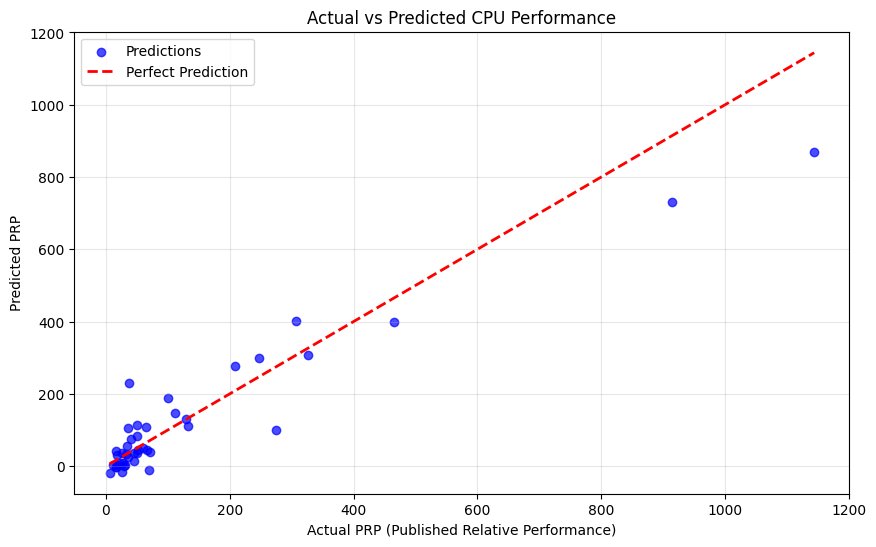

In [97]:
# Step 10: Visualize Actual vs Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual PRP (Published Relative Performance)')
plt.ylabel('Predicted PRP')
plt.title('Actual vs Predicted CPU Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

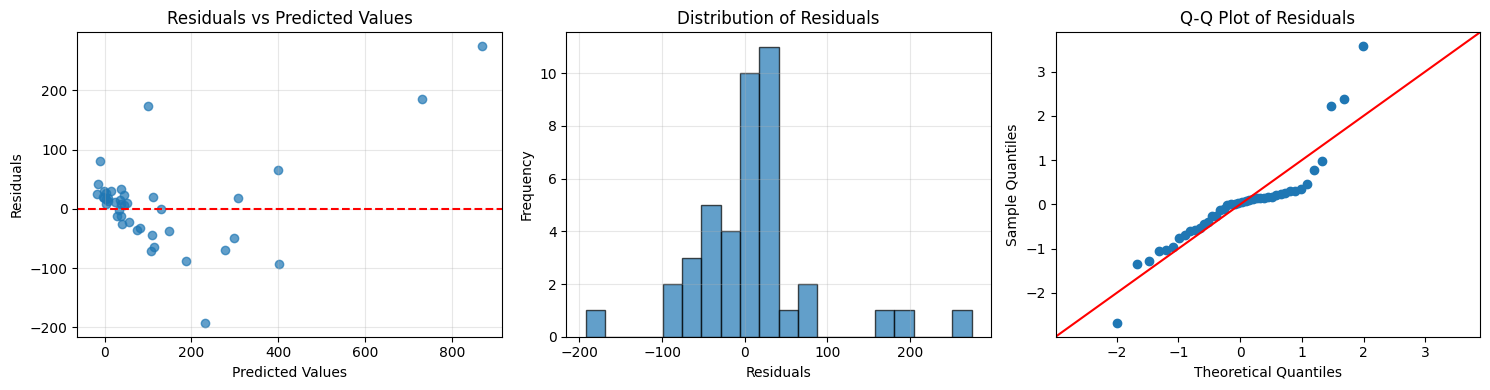

Residual Statistics:
Mean: 7.5719
Std: 75.5760
Min: -192.3930
Max: 274.4820


In [98]:
# Step 11: Analyze residuals
residuals = y_test - y_pred

plt.figure(figsize=(15, 4))

# Plot 1: Residuals vs Predicted
plt.subplot(1, 3, 1)
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.grid(True, alpha=0.3)

# Plot 2: Histogram of residuals
plt.subplot(1, 3, 2)
plt.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True, alpha=0.3)

# Plot 3: Q-Q plot for normality
plt.subplot(1, 3, 3)
sm.qqplot(residuals, line='45', fit=True, ax=plt.gca())
plt.title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

print(f"Residual Statistics:")
print(f"Mean: {residuals.mean():.4f}")
print(f"Std: {residuals.std():.4f}")
print(f"Min: {residuals.min():.4f}")
print(f"Max: {residuals.max():.4f}")

In [99]:
# Step 12: Interpret significant features
print("="*60)
print("SIGNIFICANT FEATURES ANALYSIS (p < 0.05)")
print("="*60)

significant_features = results.pvalues[results.pvalues < 0.05]
print(f"Number of significant features: {len(significant_features) - 1}")

print("\nSignificant features with coefficients:")
for feature, pval in significant_features.items():
    if feature != 'const':
        coef = results.params[feature]
        print(f"{feature:10s}: Coefficient = {coef:8.4f}, p-value = {pval:.6f}")

print(f"\nModel Intercept: {results.params['const']:.4f}")

SIGNIFICANT FEATURES ANALYSIS (p < 0.05)
Number of significant features: 5

Significant features with coefficients:
MYCT      : Coefficient =   0.0428, p-value = 0.020501
MMIN      : Coefficient =   0.0111, p-value = 0.000002
MMAX      : Coefficient =   0.0060, p-value = 0.000000
CACH      : Coefficient =   0.6213, p-value = 0.000031
CHMAX     : Coefficient =   1.3829, p-value = 0.000000

Model Intercept: -49.6937


In [100]:
# Step 13: Simple Linear Regression Example (Manual Calculation)
def estimate_coef(x,y) :
    #number of obs/pts
    n = np.size(x)

    #mean of x and y vector
    m_x = np.mean(x)
    m_y = np.mean(y)

    #calculating cross-deviation and devviation about x

    SS_xy = np.sum(y*x) - n*m_y*m_x
    SS_xx = np.sum(x*x) - n*m_x*m_x

    # calculating regression const
    b_1 = SS_xy / SS_xx
    b_0 = m_y - b_1*m_x

    return(b_0,b_1)

In [ ]:
def plot_regression_line(x, y, b, x_label='x', y_label='y', title='Linear Regression'):
    """Plot regression line"""
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, color="blue", marker="o", s=30, alpha=0.7, label='Data points')
    
    # Predicted values
    y_pred = b[0] + b[1] * x
    
    # Plot regression line
    plt.plot(x, y_pred, color="red", linewidth=2, label='Regression line')
    
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return y_pred

SIMPLE LINEAR REGRESSION: MMIN vs PRP
Manual calculation results:
Intercept (b_0): 12.3783
Slope (b_1): 0.0313

Interpretation: For every 1KB increase in minimum memory,
CPU performance increases by 0.0313 units


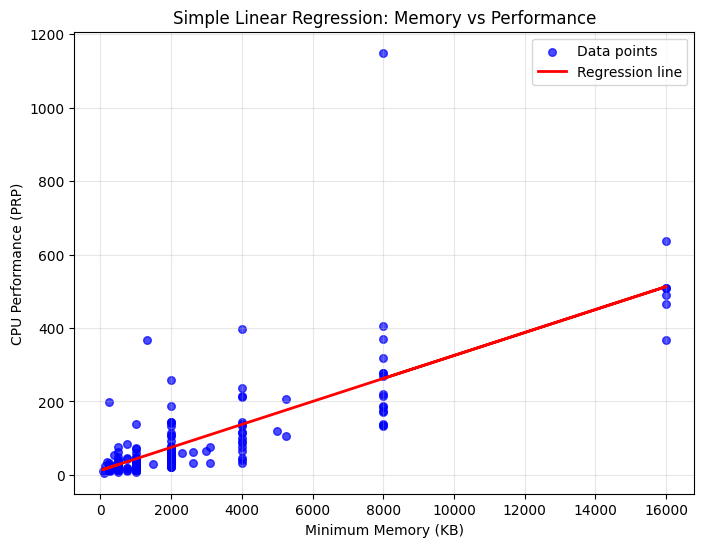


R² for simple regression: 0.5761
Simple model explains 57.61% of variance


In [101]:
# Step 14: Example of simple linear regression with one feature
print("="*60)
print("SIMPLE LINEAR REGRESSION: MMIN vs PRP")
print("="*60)

# Use minimum memory (MMIN) as predictor
x_simple = X_train['MMIN'].values
y_simple = y_train.values

# Estimate coefficients manually
b_simple = estimate_coef(x_simple, y_simple)
print(f"Manual calculation results:")
print(f"Intercept (b_0): {b_simple[0]:.4f}")
print(f"Slope (b_1): {b_simple[1]:.4f}")
print(f"\nInterpretation: For every 1KB increase in minimum memory,")
print(f"CPU performance increases by {b_simple[1]:.4f} units")

# Plot
y_pred_simple = plot_regression_line(
    x_simple, y_simple, b_simple,
    x_label='Minimum Memory (KB)', 
    y_label='CPU Performance (PRP)',
    title='Simple Linear Regression: Memory vs Performance'
)

# Calculate R²
ss_res = np.sum((y_simple - y_pred_simple) ** 2)
ss_tot = np.sum((y_simple - np.mean(y_simple)) ** 2)
r2_simple = 1 - (ss_res / ss_tot)
print(f"\nR² for simple regression: {r2_simple:.4f}")
print(f"Simple model explains {r2_simple*100:.2f}% of variance")

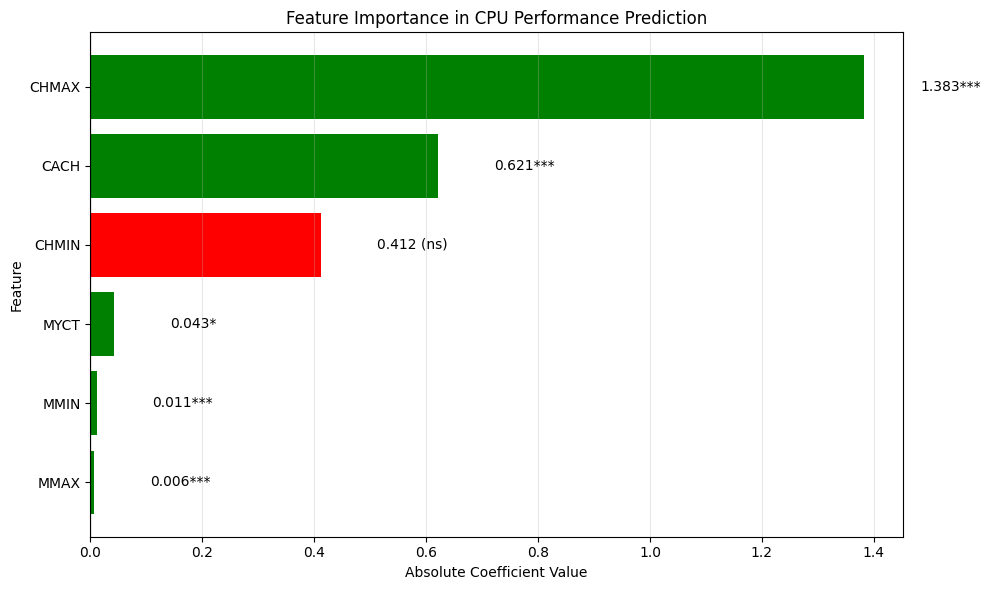


Feature Importance Summary:
Feature  Coefficient  Absolute_Coef      P_value
  CHMAX     1.382874       1.382874 1.151493e-07
   CACH     0.621287       0.621287 3.104730e-05
  CHMIN     0.411682       0.411682 7.037944e-01
   MYCT     0.042756       0.042756 2.050100e-02
   MMIN     0.011096       0.011096 2.239731e-06
   MMAX     0.005968       0.005968 3.427878e-15


In [102]:
# Step 15: Feature importance visualization
feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': [results.params[f] for f in features],
    'Absolute_Coef': [abs(results.params[f]) for f in features],
    'P_value': [results.pvalues[f] for f in features]
})

# Sort by absolute coefficient value
feature_importance = feature_importance.sort_values('Absolute_Coef', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['green' if p < 0.05 else 'red' for p in feature_importance['P_value']]
plt.barh(feature_importance['Feature'], feature_importance['Absolute_Coef'], color=colors)
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.title('Feature Importance in CPU Performance Prediction')
plt.grid(True, alpha=0.3, axis='x')
plt.axvline(x=0, color='black', linewidth=0.8)

# Add significance labels
for i, (coef, pval) in enumerate(zip(feature_importance['Coefficient'], feature_importance['P_value'])):
    significance = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ' (ns)'
    plt.text(abs(coef) + 0.1, i, f'{coef:.3f}{significance}', va='center')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nFeature Importance Summary:")
print(feature_importance.to_string(index=False))

In [103]:
# Step 17: Make sample prediction
print("="*60)
print("SAMPLE PREDICTION EXAMPLE")
print("="*60)

# Create a sample CPU configuration
sample_cpu = pd.DataFrame({
    'MYCT': [150],    # Machine cycle time in ns (faster is better)
    'MMIN': [8000],   # Minimum memory in KB
    'MMAX': [64000],  # Maximum memory in KB
    'CACH': [128],    # Cache memory in KB
    'CHMIN': [8],     # Minimum channels
    'CHMAX': [32]     # Maximum channels
})

print("\nSample CPU Configuration:")
for feature in features:
    print(f"  {feature}: {sample_cpu[feature].values[0]}")

# Add constant for prediction
sample_cpu_const = sm.add_constant(sample_cpu, has_constant='add')

# Predict performance
predicted_prp = results.predict(sample_cpu_const)[0]
print(f"\nPredicted Performance (PRP): {predicted_prp:.2f}")

# Compare with average
print(f"Average CPU Performance: {y.mean():.2f}")
print(f"This CPU is {((predicted_prp/y.mean())-1)*100:.1f}% {'above' if predicted_prp > y.mean() else 'below'} average")

SAMPLE PREDICTION EXAMPLE

Sample CPU Configuration:
  MYCT: 150
  MMIN: 8000
  MMAX: 64000
  CACH: 128
  CHMIN: 8
  CHMAX: 32

Predicted Performance (PRP): 554.51
Average CPU Performance: 105.62
This CPU is 425.0% above average


Dataset loaded successfully!
Dataset shape: (209, 10)

First 5 rows of the dataset:
  vendor_name model_name  MYCT  MMIN   MMAX  CACH  CHMIN  CHMAX  PRP  ERP
0     adviser      32/60   125   256   6000   256     16    128  198  199
1      amdahl     470v/7    29  8000  32000    32      8     32  269  253
2      amdahl    470v/7a    29  8000  32000    32      8     32  220  253
3      amdahl    470v/7b    29  8000  32000    32      8     32  172  253
4      amdahl    470v/7c    29  8000  16000    32      8     16  132  132

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   vendor_name  209 non-null    object
 1   model_name   209 non-null    object
 2   MYCT         209 non-null    int64 
 3   MMIN         209 non-null    int64 
 4   MMAX         209 non-null    int64 
 5   CACH         209 non-null    int64 
 6   CHMIN        209 no

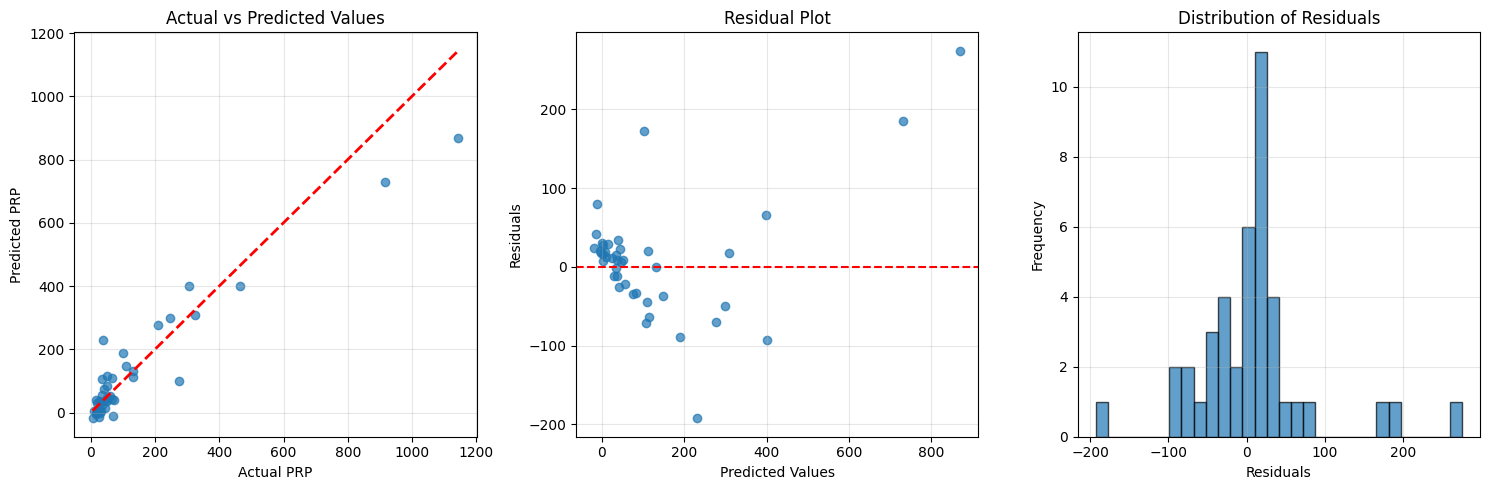


ASSUMPTION CHECKS


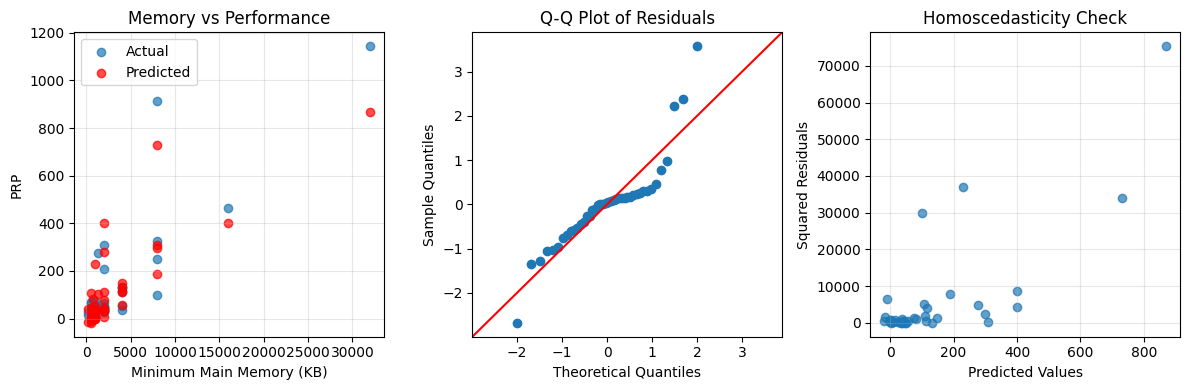


INTERPRETATION OF RESULTS

Most Significant Features (based on p-values < 0.05):
  MYCT: Coefficient = 0.0428, p-value = 0.0205
  MMIN: Coefficient = 0.0111, p-value = 0.0000
  MMAX: Coefficient = 0.0060, p-value = 0.0000
  CACH: Coefficient = 0.6213, p-value = 0.0000
  CHMAX: Coefficient = 1.3829, p-value = 0.0000

Model Intercept: -49.6937
Number of significant features: 5

Feature Importance (Absolute Coefficients):
  Feature  Coefficient  Absolute_Coefficient
5   CHMAX     1.382874              1.382874
3    CACH     0.621287              0.621287
4   CHMIN     0.411682              0.411682
0    MYCT     0.042756              0.042756
1    MMIN     0.011096              0.011096
2    MMAX     0.005968              0.005968

SIMPLE LINEAR REGRESSION EXAMPLE
Simple Linear Regression Coefficients:
  Intercept (b_0): 12.3783
  Slope (b_1): 0.0313


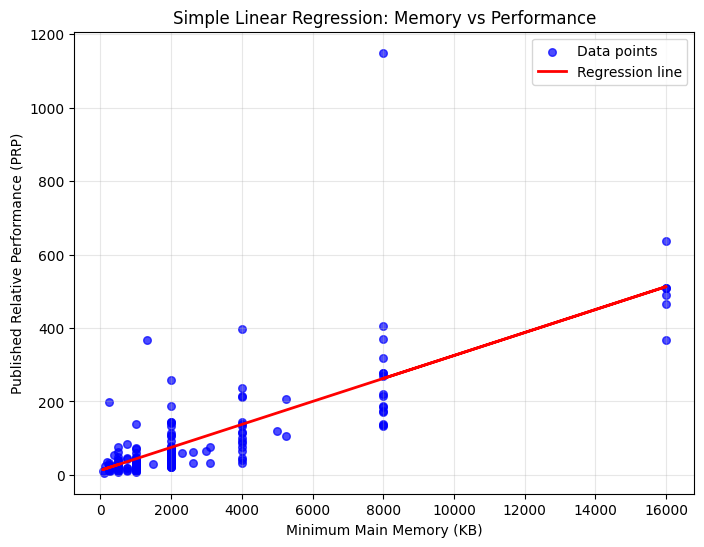

R² for simple regression: 0.5761

MODEL VALIDATION SUMMARY
1. The model explains 88.93% of the variance in CPU performance.
2. Root Mean Squared Error: 75.05
3. Model uses 6 features to predict performance.
4. 5 features are statistically significant (p < 0.05).
5. Residual analysis shows:
   - Mean of residuals: 7.5719 (should be near 0)
   - Standard deviation of residuals: 75.5760

Business Insights:
1. Most important features affecting CPU performance:
   - CHMAX: increases performance by 1.3829 per unit
   - CACH: increases performance by 0.6213 per unit
   - CHMIN: increases performance by 0.4117 per unit
2. Model can be used for:
   - Predicting CPU performance for new hardware configurations
   - Understanding which hardware specs most impact performance
   - Optimizing hardware configurations for target performance levels

Recommendations for Improvement:
1. Consider feature engineering (log transformations, interactions)
2. Check for multicollinearity using VIF
3. Try regular

In [88]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ============================
# Step 1: Load the dataset
# ============================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/cpu-performance/machine.data"

col_names = ['vendor_name', 'model_name', 'MYCT', 'MMIN', 'MMAX', 'CACH', 
             'CHMIN', 'CHMAX', 'PRP', 'ERP']
# Based on UCI description: PRP is the published relative performance (target)
# ERP is the estimated relative performance (alternative target)

data = pd.read_csv(url, header=None, names=col_names)
print("Dataset loaded successfully!")
print(f"Dataset shape: {data.shape}")
print("\nFirst 5 rows of the dataset:")
print(data.head())
print("\nDataset Info:")
print(data.info())
print("\nMissing values:")
print(data.isnull().sum())

# ============================
# Step 2: Purpose of the Model
# ============================
"""
Purpose: To predict the "PRP" (published relative performance) of a CPU 
based on its hardware specifications.

Dependent Variable (y): "PRP" - Published relative performance (target variable)

Independent Variables (X): 
- MYCT: machine cycle time in nanoseconds
- MMIN: minimum main memory in kilobytes
- MMAX: maximum main memory in kilobytes
- CACH: cache memory in kilobytes
- CHMIN: minimum channels in units
- CHMAX: maximum channels in units
- ERP: estimated relative performance (could be used as feature or not)

We'll exclude vendor_name and model_name as they are categorical identifiers.
"""

# ============================
# Step 3: Data Preprocessing
# ============================
# Check for any missing values
print("\nChecking for missing values...")
print(data.isnull().sum())

# No missing values, so we can use all data
print(f"\nTotal samples available: {len(data)}")

# Select features and target
features = ['MYCT', 'MMIN', 'MMAX', 'CACH', 'CHMIN', 'CHMAX']  # Excluding ERP to avoid data leakage
X = data[features]
y = data['PRP']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Show basic statistics
print("\nFeature Statistics:")
print(X.describe())
print("\nTarget Statistics:")
print(f"Mean PRP: {y.mean():.2f}")
print(f"Min PRP: {y.min():.2f}")
print(f"Max PRP: {y.max():.2f}")
print(f"Std PRP: {y.std():.2f}")

# ============================
# Step 4: Train-Test Split
# ============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

# ============================
# Step 5: Build Linear Regression Model
# ============================
# Add constant for intercept term
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Create and fit the model
model = sm.OLS(y_train, X_train_const)
results = model.fit()

print("\n" + "="*50)
print("LINEAR REGRESSION RESULTS")
print("="*50)
print(results.summary())

# ============================
# Step 6: Make Predictions
# ============================
# Predict on test set
y_pred = results.predict(X_test_const)

# ============================
# Step 7: Evaluate the Model
# ============================
# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²) Score: {r2:.4f}")

# ============================
# Step 8: Visualize Results
# ============================
# Plot 1: Actual vs Predicted
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual PRP')
plt.ylabel('Predicted PRP')
plt.title('Actual vs Predicted Values')
plt.grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test - y_pred
plt.subplot(1, 3, 2)
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

# Plot 3: Distribution of Residuals
plt.subplot(1, 3, 3)
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================
# Step 9: Check Key Assumptions
# ============================
print("\n" + "="*50)
print("ASSUMPTION CHECKS")
print("="*50)

# 1. Linearity check (using one key feature as example)
plt.figure(figsize=(12, 4))

# Plot relationship between MMIN and PRP
plt.subplot(1, 3, 1)
plt.scatter(X_test['MMIN'], y_test, alpha=0.7, label='Actual')
plt.scatter(X_test['MMIN'], y_pred, alpha=0.7, label='Predicted', color='red')
plt.xlabel('Minimum Main Memory (KB)')
plt.ylabel('PRP')
plt.title('Memory vs Performance')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Q-Q plot for normality check
plt.subplot(1, 3, 2)
sm.qqplot(residuals, line='45', fit=True, ax=plt.gca())
plt.title('Q-Q Plot of Residuals')

# 3. Homoscedasticity check
plt.subplot(1, 3, 3)
plt.scatter(y_pred, residuals**2, alpha=0.7)
plt.xlabel('Predicted Values')
plt.ylabel('Squared Residuals')
plt.title('Homoscedasticity Check')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================
# Step 10: Interpret Results
# ============================
print("\n" + "="*50)
print("INTERPRETATION OF RESULTS")
print("="*50)
print("\nMost Significant Features (based on p-values < 0.05):")
significant_features = results.pvalues[results.pvalues < 0.05]
for feature, pval in significant_features.items():
    if feature != 'const':
        coef = results.params[feature]
        print(f"  {feature}: Coefficient = {coef:.4f}, p-value = {pval:.4f}")

print(f"\nModel Intercept: {results.params['const']:.4f}")
print(f"Number of significant features: {len(significant_features) - 1}")

# Show feature importance (absolute coefficients)
print("\nFeature Importance (Absolute Coefficients):")
coef_importance = pd.DataFrame({
    'Feature': [f for f in features],
    'Coefficient': [results.params[f] for f in features],
    'Absolute_Coefficient': [abs(results.params[f]) for f in features]
})
coef_importance = coef_importance.sort_values('Absolute_Coefficient', ascending=False)
print(coef_importance)

# ============================
# Step 11: Simple Linear Regression Example
# ============================
def estimate_coef(x, y):
    """Calculate linear regression coefficients manually"""
    n = np.size(x)
    m_x = np.mean(x)
    m_y = np.mean(y)
    
    SS_xy = np.sum(y * x) - n * m_y * m_x
    SS_xx = np.sum(x * x) - n * m_x * m_x
    
    b_1 = SS_xy / SS_xx
    b_0 = m_y - b_1 * m_x
    
    return b_0, b_1

def plot_regression_line(x, y, b, x_label='x', y_label='y', title='Linear Regression'):
    """Plot regression line"""
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, color="blue", marker="o", s=30, alpha=0.7, label='Data points')
    
    # Predicted values
    y_pred = b[0] + b[1] * x
    
    # Plot regression line
    plt.plot(x, y_pred, color="red", linewidth=2, label='Regression line')
    
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return y_pred

# Example: Simple linear regression with MMIN (minimum memory)
print("\n" + "="*50)
print("SIMPLE LINEAR REGRESSION EXAMPLE")
print("="*50)

x_simple = X_train['MMIN'].values
y_simple = y_train.values

# Estimate coefficients
b_simple = estimate_coef(x_simple, y_simple)
print(f"Simple Linear Regression Coefficients:")
print(f"  Intercept (b_0): {b_simple[0]:.4f}")
print(f"  Slope (b_1): {b_simple[1]:.4f}")

# Plot the regression line
y_pred_simple = plot_regression_line(x_simple, y_simple, b_simple, 
                                     x_label='Minimum Main Memory (KB)', 
                                     y_label='Published Relative Performance (PRP)',
                                     title='Simple Linear Regression: Memory vs Performance')

# Calculate R² for simple regression
ss_res = np.sum((y_simple - y_pred_simple) ** 2)
ss_tot = np.sum((y_simple - np.mean(y_simple)) ** 2)
r2_simple = 1 - (ss_res / ss_tot)
print(f"R² for simple regression: {r2_simple:.4f}")

# ============================
# Step 12: Model Validation and Final Summary
# ============================
print("\n" + "="*50)
print("MODEL VALIDATION SUMMARY")
print("="*50)
print(f"1. The model explains {r2*100:.2f}% of the variance in CPU performance.")
print(f"2. Root Mean Squared Error: {rmse:.2f}")
print(f"3. Model uses {len(features)} features to predict performance.")
print(f"4. {len(significant_features)-1} features are statistically significant (p < 0.05).")
print("5. Residual analysis shows:")
print(f"   - Mean of residuals: {residuals.mean():.4f} (should be near 0)")
print(f"   - Standard deviation of residuals: {residuals.std():.4f}")

print("\nBusiness Insights:")
print("1. Most important features affecting CPU performance:")
for idx, row in coef_importance.head(3).iterrows():
    direction = "increases" if row['Coefficient'] > 0 else "decreases"
    print(f"   - {row['Feature']}: {direction} performance by {abs(row['Coefficient']):.4f} per unit")
print("2. Model can be used for:")
print("   - Predicting CPU performance for new hardware configurations")
print("   - Understanding which hardware specs most impact performance")
print("   - Optimizing hardware configurations for target performance levels")

print("\nRecommendations for Improvement:")
print("1. Consider feature engineering (log transformations, interactions)")
print("2. Check for multicollinearity using VIF")
print("3. Try regularization (Ridge/Lasso) if overfitting is suspected")
print("4. Consider non-linear models if linearity assumptions are violated")

# ============================
# Bonus: Make a sample prediction
# ============================
print("\n" + "="*50)
print("SAMPLE PREDICTION")
print("="*50)

# Create a sample CPU configuration
sample_cpu = pd.DataFrame({
    'MYCT': [200],    # Machine cycle time (ns)
    'MMIN': [4000],   # Minimum memory (KB)
    'MMAX': [32000],  # Maximum memory (KB)
    'CACH': [64],     # Cache memory (KB)
    'CHMIN': [4],     # Minimum channels
    'CHMAX': [16]     # Maximum channels
})

# Add constant for prediction
sample_cpu_const = sm.add_constant(sample_cpu, has_constant='add')

# Predict performance
predicted_prp = results.predict(sample_cpu_const)[0]
print(f"\nSample CPU Configuration:")
for feature in features:
    print(f"  {feature}: {sample_cpu[feature].values[0]}")
print(f"\nPredicted Performance (PRP): {predicted_prp:.2f}")